In [1]:
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import matplotlib.animation as ma
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
from matplotlib.cm import ScalarMappable
from matplotlib import gridspec
from tqdm.notebook import tqdm
from itertools import product
import pandas as pd
import numpy as np
import numba as nb
import imageio
import pickle
import json
import os
import shutil
import sys
sys.path.append("..")

from main import *

randomSeed = 100

%matplotlib inline
%config InlineBackend.figure_format = "retina"

new_cmap = mcolors.LinearSegmentedColormap.from_list(
    "new", plt.cm.hsv(np.linspace(0, 1, 256)) * 0.85, N=256
)

@nb.njit
def colors_idx(phaseTheta):
    return np.floor(256 - phaseTheta / (2 * np.pi) * 256).astype(np.int32)

with open("../swarmalatorlib/hex_colors.json", "r", encoding="utf-8") as f:
    hexColors = json.load(f)
hexCmap = mcolors.LinearSegmentedColormap.from_list("cmap", hexColors)


import seaborn as sns

sns.set_theme(
    style="ticks", 
    font_scale=1.1, rc={
    'figure.figsize': (6, 5),
    'axes.facecolor': 'white',
    'figure.facecolor': 'white',
    'grid.color': '#dddddd',
    'grid.linewidth': 0.5,
    "lines.linewidth": 1.5,
    'text.color': '#000000',
    'figure.titleweight': "bold",
    'xtick.color': '#000000',
    'ytick.color': '#000000'
})

plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
#plt.rcParams['animation.ffmpeg_path'] = "/opt/conda/bin/ffmpeg"

from multiprocessing import Pool
import pandas as pd

colors = ["#403990", "#3A76D6", "#FFC001", "#F46F43", "#C70000FF"]
cmap = mcolors.LinearSegmentedColormap.from_list("cmap", colors)
cmap_r = mcolors.LinearSegmentedColormap.from_list("my_colormap", colors[::-1])

colors = ["#403990", "#80A6E2", "#F46F43", "#CF3D3E"]
cmap2 = mcolors.LinearSegmentedColormap.from_list("cmap2", colors)

SAVE_PATH = r"F:\MS_ExperimentData\general"
MP4_PATH = r"F:\MS_ExperimentData\mp4"

# SAVE_PATH = r"D:\MS_ExperimentData\general"
# MP4_PATH = r"D:\MS_ExperimentData\mp4"

# LOCAL_FIG_PATH = "./PCT_C_figs"
LOCAL_FIG_PATH = "./figs"


In [2]:
model = FVK(
    strengthK=20, distanceD0=1.5, phaseLagA0=0.6 * np.pi,
    omegaMin=0, deltaOmega=0,
    agentsNum=2000, dt=0.005,
    tqdm=True, savePath=SAVE_PATH, shotsnaps=1, 
    randomSeed=10, overWrite=False
)

In [3]:
model.run(80000)

F:\MS_ExperimentData\general/FVK(strengthK=20.000,distanceD0=1.500,phaseLagA0=1.885,boundaryLength=7.0,speedV=3.0,freqDist=uniform,omegaMin=0.000,deltaOmega=0.000,agentsNum=2000,dt=0.005,shotsnaps=1,randomSeed=10).h5 already exists, but has only 60593 snapshots, will continue to run until 80001 snapshots.


100%|█████████████████████████████████████████████████████████| 19408/19408 [48:16<00:00,  6.70it/s]


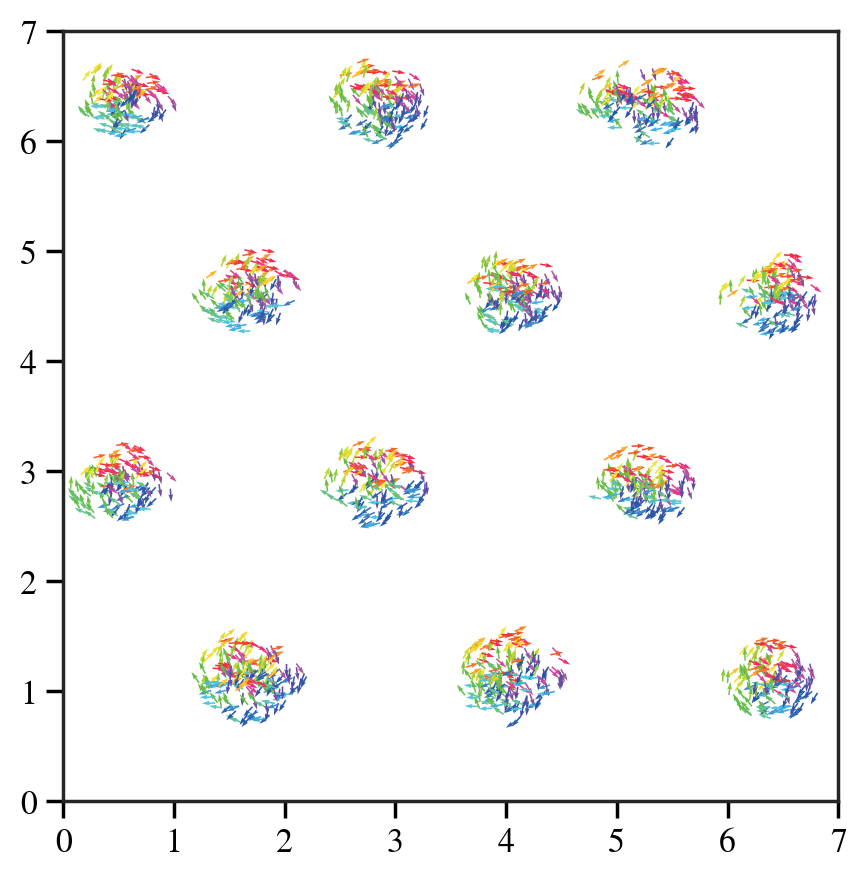

In [4]:
model.plot()

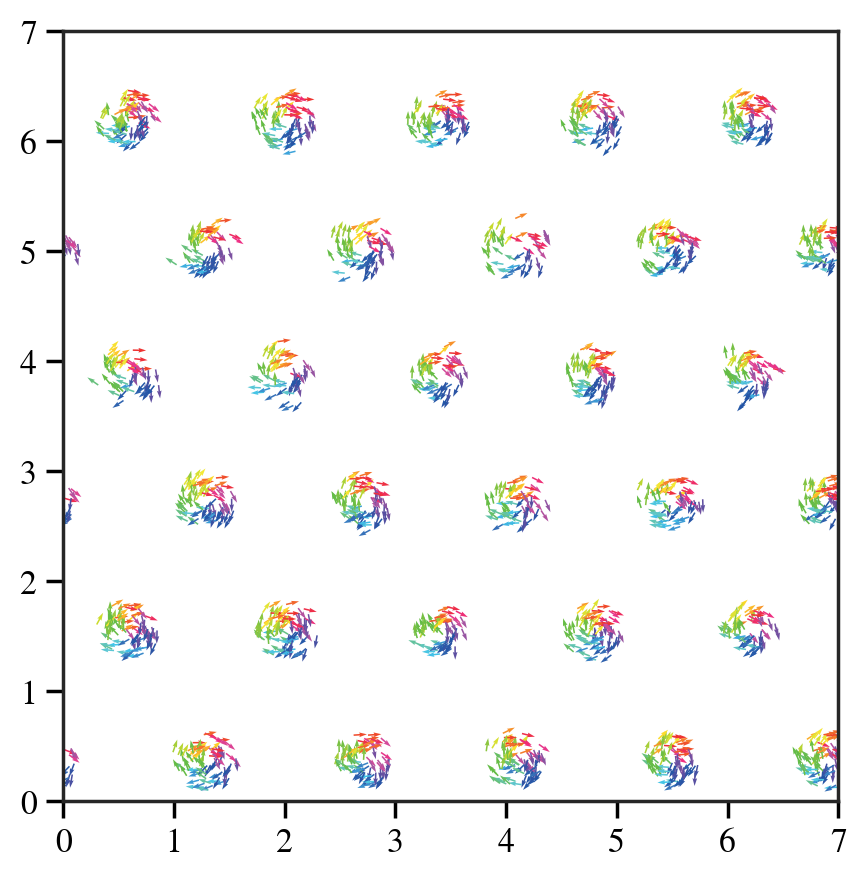

In [2]:
model = FVK(
    strengthK=20, distanceD0=1, phaseLagA0=0.6 * np.pi,
    omegaMin=0, deltaOmega=1,
    agentsNum=2000, dt=0.005,
    tqdm=True, savePath=SAVE_PATH, shotsnaps=10, 
    randomSeed=10, overWrite=False
)
sa = StateAnalysis(model)
sa.plot_spatial()

In [3]:
shift = np.array([0., 0.])

classes, centers = sa.calc_classes_and_centers(classDistance=0.5, lookIdx=-1)
centers = np.mod(centers + shift, model.boundaryLength)

classCenters: List[np.ndarray] = []
for c in classes:
    singleClassCenters = centers[c]

    maxDeltaX = np.abs(singleClassCenters[:, 0] - singleClassCenters[:, 0, np.newaxis]).max()
    subXShift = model.halfBoundaryLength if maxDeltaX > model.halfBoundaryLength else 0
    maxDeltaY = np.abs(singleClassCenters[:, 1] - singleClassCenters[:, 1, np.newaxis]).max()
    subYShift = model.halfBoundaryLength if maxDeltaY > model.halfBoundaryLength else 0

    singleClassCenters = np.mod(singleClassCenters - np.array([subXShift, subYShift]), model.boundaryLength)
    classCenter = np.mod(singleClassCenters.mean(axis=0) + np.array([subXShift, subYShift]), model.boundaryLength)
    classCenters.append(classCenter)
classCenters: np.ndarray = np.array(classCenters)

edges, ajdClassCenters = sa.calc_nearby_edges(classCenters=classCenters, stdMulti=0.3)

totalTvRadius = list()
step = 1

for idx, singleClass in enumerate(classes):
    subPositionX = sa.totalPositionX[::step, singleClass, :]
    classCenter = classCenters[idx]
    tvMaxRadius = sa.calc_relative_distance(subPositionX, classCenter).mean(axis=1)
    totalTvRadius.append(tvMaxRadius)

analysisRadius = sa.model.speedV / np.abs(sa.model.strengthK * np.sin(sa.model.phaseLagA0))
# analysisRadius = sa.model.speedV / np.abs(sa.model.strengthK)
tRanges = (np.arange(0, len(totalTvRadius[0])) * sa.model.shotsnaps * step * sa.model.dt)

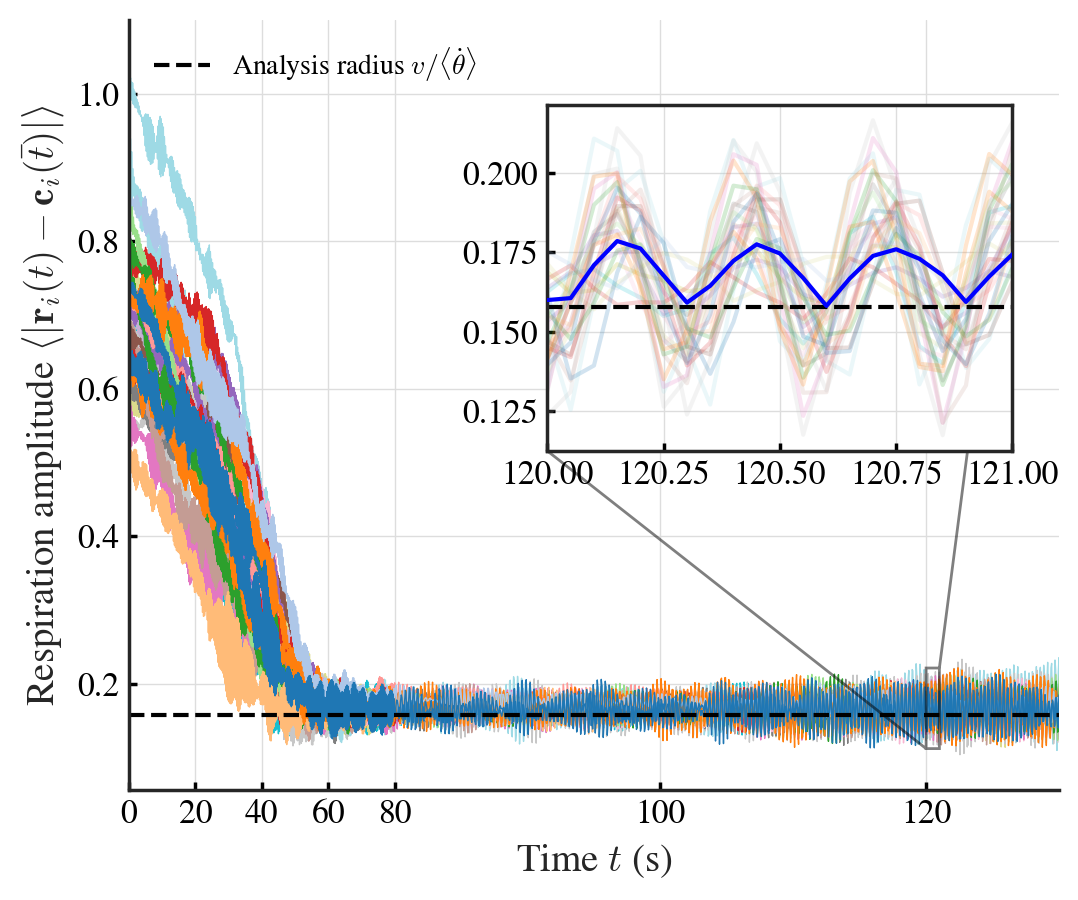

In [ ]:
fig, ax = plt.subplots()

colors = plt.cm.tab20(np.linspace(1, 0, len(totalTvRadius)))
for i, tvRadius in enumerate(totalTvRadius[:]):
    ax.plot(tRanges, tvRadius, alpha=1, lw=0.5, color=colors[i])

ax.axhline(analysisRadius, color="black", lw=1.5, ls="--", label=r"Analysis radius $v/\langle\dot{\theta}\rangle$")

ax.tick_params(length=3, direction="in")
ax.set_xlabel("Time $t$", fontsize=14)
ax.set_ylabel(r"Respiration amplitude $\left< \left| \mathbf{r}_i(t)-\mathbf{c}_i(\bar{t}) \right| \right> $", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid()
ax.set_xlim(0, 130)
ax.set_ylim(None, 1.1)
ax.legend(ncols=2, fontsize=10, loc="upper left", frameon=False)

axTide = ax.inset_axes([0.45, 0.44, 0.5, 0.45])

left = 120
right = left + 1
selectWindow = (tRanges >= left) & (tRanges <= right)

meanFreqs = []
for i, tvRadius in enumerate(totalTvRadius[:]):
    if i == 15:  # 2
        zorder, alpha, color = 100, 1, "blue"
    else:
        zorder, alpha, color = 1, 0.2, colors[i]
    axTide.plot(tRanges[selectWindow], tvRadius[selectWindow], alpha=alpha, lw=1.5, 
                color=color, ls="-", zorder=zorder)

axTide.axhline(analysisRadius, color="black", lw=1.5, ls="--")

ax.indicate_inset_zoom(axTide, linewidth=1, edgecolor="black")
axTide.tick_params(length=3, direction="in")
axTide.grid()
axTide.set_xlim(left, right)
# axTide.set_xticks([135, 137.5, 140])

def forward(x):
    return np.where(x < 80, x/2, 40 + (x-80)*2)

def inverse(x):
    return np.where(x < 40, x*2, 80 + (x-40)/2)

ax.set_xscale('function', functions=(forward, inverse))
# ax.set_aspect(60)

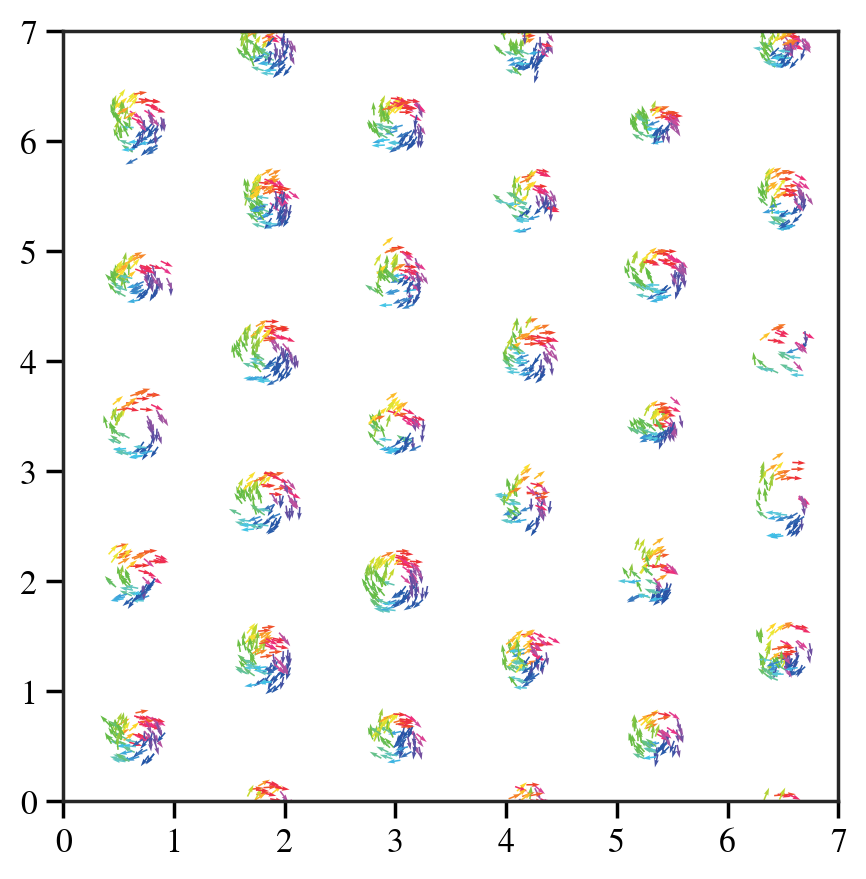

In [9]:
model = FVK(
    strengthK=20, distanceD0=1, phaseLagA0=0.6 * np.pi,
    omegaMin=0, deltaOmega=0,
    agentsNum=2000, dt=0.005,
    tqdm=True, savePath=SAVE_PATH, shotsnaps=10, 
    randomSeed=10, overWrite=False
)
sa = StateAnalysis(model)
sa.plot_spatial()

In [10]:
shift = np.array([0., 0.])

classes, centers = sa.calc_classes_and_centers(classDistance=0.5, lookIdx=-1)
centers = np.mod(centers + shift, model.boundaryLength)

classCenters: List[np.ndarray] = []
for c in classes:
    singleClassCenters = centers[c]

    maxDeltaX = np.abs(singleClassCenters[:, 0] - singleClassCenters[:, 0, np.newaxis]).max()
    subXShift = model.halfBoundaryLength if maxDeltaX > model.halfBoundaryLength else 0
    maxDeltaY = np.abs(singleClassCenters[:, 1] - singleClassCenters[:, 1, np.newaxis]).max()
    subYShift = model.halfBoundaryLength if maxDeltaY > model.halfBoundaryLength else 0

    singleClassCenters = np.mod(singleClassCenters - np.array([subXShift, subYShift]), model.boundaryLength)
    classCenter = np.mod(singleClassCenters.mean(axis=0) + np.array([subXShift, subYShift]), model.boundaryLength)
    classCenters.append(classCenter)
classCenters: np.ndarray = np.array(classCenters)

edges, ajdClassCenters = sa.calc_nearby_edges(classCenters=classCenters, stdMulti=0.3)

totalTvRadius = list()
step = 1

for idx, singleClass in enumerate(classes):
    subPositionX = sa.totalPositionX[::step, singleClass, :]
    classCenter = classCenters[idx]
    tvMaxRadius = sa.calc_relative_distance(subPositionX, classCenter).mean(axis=1)
    totalTvRadius.append(tvMaxRadius)

analysisRadius = sa.model.speedV / np.abs(sa.model.strengthK * np.sin(sa.model.phaseLagA0))
# analysisRadius = sa.model.speedV / np.abs(sa.model.strengthK)
tRanges = (np.arange(0, len(totalTvRadius[0])) * sa.model.shotsnaps * step * sa.model.dt)

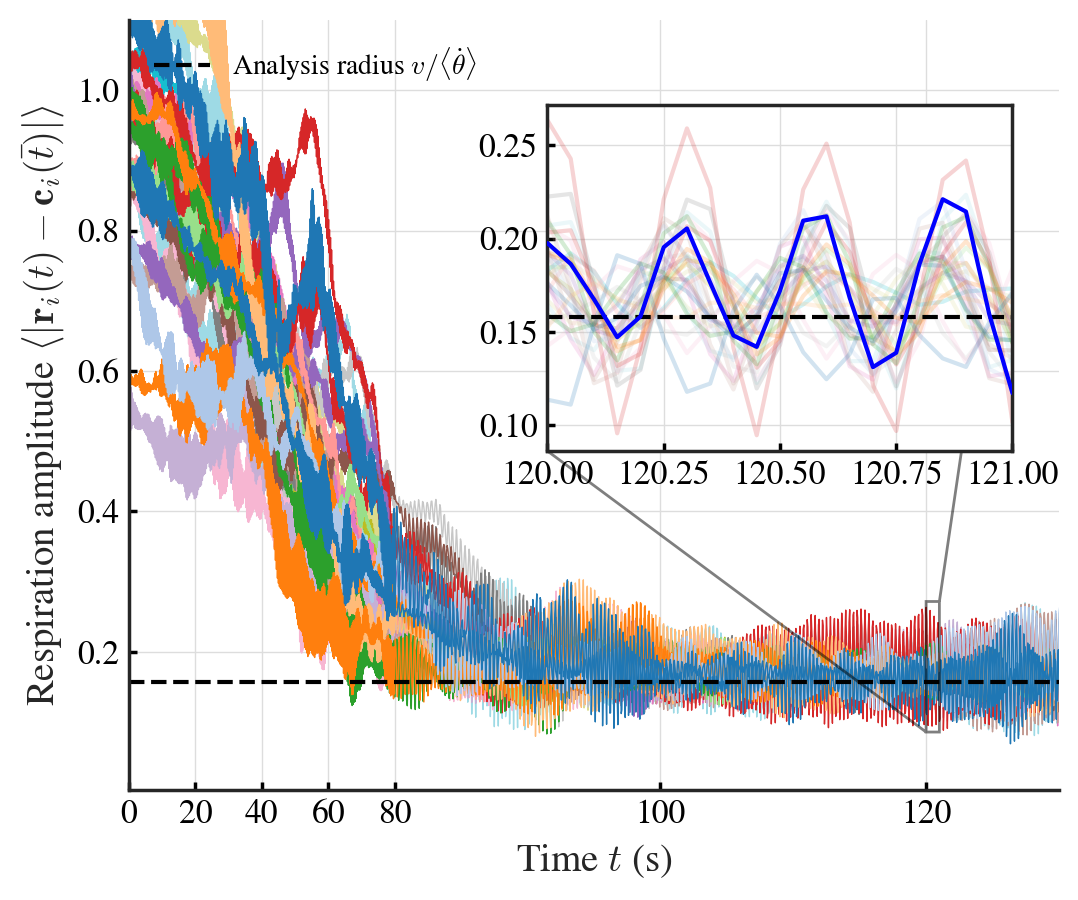

In [11]:
fig, ax = plt.subplots()

colors = plt.cm.tab20(np.linspace(1, 0, len(totalTvRadius)))
for i, tvRadius in enumerate(totalTvRadius[:]):
    ax.plot(tRanges, tvRadius, alpha=1, lw=0.5, color=colors[i])

ax.axhline(analysisRadius, color="black", lw=1.5, ls="--", label=r"Analysis radius $v/\langle\dot{\theta}\rangle$")

ax.tick_params(length=3, direction="in")
ax.set_xlabel("Time $t$ (s)", fontsize=14)
ax.set_ylabel(r"Respiration amplitude $\left< \left| \mathbf{r}_i(t)-\mathbf{c}_i(\bar{t}) \right| \right> $", fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid()
ax.set_xlim(0, 130)
ax.set_ylim(None, 1.1)
ax.legend(ncols=2, fontsize=10, loc="upper left", frameon=False)

axTide = ax.inset_axes([0.45, 0.44, 0.5, 0.45])

left = 120
right = left + 1
selectWindow = (tRanges >= left) & (tRanges <= right)

meanFreqs = []
for i, tvRadius in enumerate(totalTvRadius[:]):
    if i == 15:  # 2
        zorder, alpha, color = 100, 1, "blue"
    else:
        zorder, alpha, color = 1, 0.2, colors[i]
    axTide.plot(tRanges[selectWindow], tvRadius[selectWindow], alpha=alpha, lw=1.5, 
                color=color, ls="-", zorder=zorder)

axTide.axhline(analysisRadius, color="black", lw=1.5, ls="--")

ax.indicate_inset_zoom(axTide, linewidth=1, edgecolor="black")
axTide.tick_params(length=3, direction="in")
axTide.grid()
axTide.set_xlim(left, right)
# axTide.set_xticks([135, 137.5, 140])

def forward(x):
    return np.where(x < 80, x/2, 40 + (x-80)*2)

def inverse(x):
    return np.where(x < 40, x*2, 80 + (x-40)/2)

ax.set_xscale('function', functions=(forward, inverse))
# ax.set_aspect(60)